<a href="https://colab.research.google.com/github/noyeem99/dp-text-classification-opacus.ipynb/blob/main/Copy_of_dp_sgd_privacy_utility_tradeoff_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

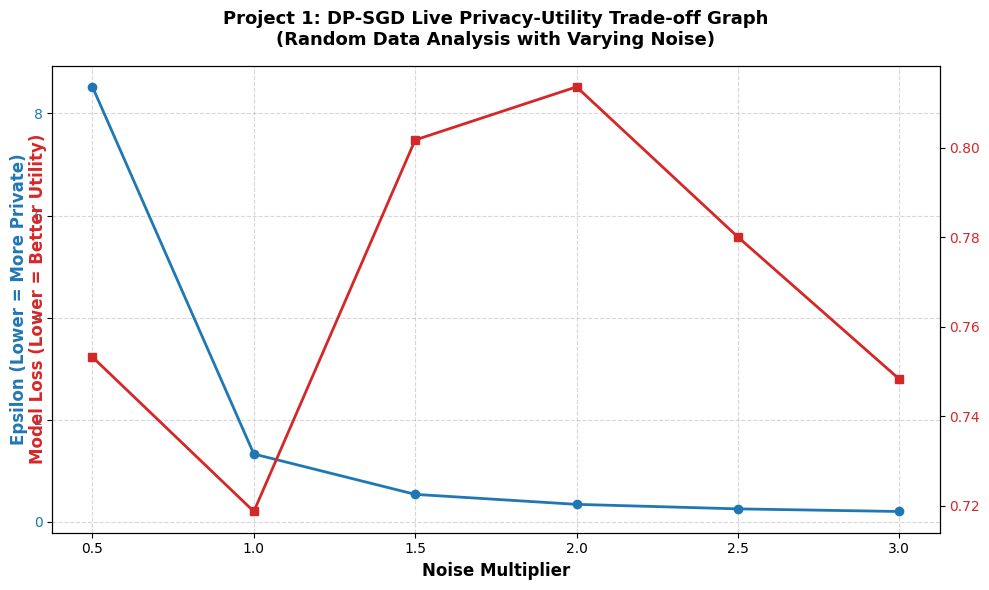


--- Final Evaluation Metrics ---
Noise Multiplier   | Epsilon (ε)  | Model Loss
--------------------------------------------------
0.5                | 8.52         | 0.7532    
1.0                | 1.33         | 0.7187    
1.5                | 0.54         | 0.8017    
2.0                | 0.34         | 0.8136    
2.5                | 0.25         | 0.7800    
3.0                | 0.20         | 0.7483    


In [ ]:
# =====================================================================
# 1. DEPENDENCY INSTALLATION (Colab Native)
# =====================================================================
!pip install opacus==1.4.0 torch torchvision matplotlib --quiet

# =====================================================================
# 2. MAIN SOURCE CODE FOR PROJECT 1
# =====================================================================
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from opacus import PrivacyEngine
import matplotlib.pyplot as plt
from IPython import display

print("📦 Packages loaded successfully!")
print("🚀 Starting DP-SGD Privacy-Utility Trade-off Analysis...\n")

# --- 1. Synthetic Dataset Generation (Random Data) ---
# Generating 10,000 random samples with 10 features for binary classification
X_random = torch.randn(10000, 10)
y_random = torch.randint(0, 2, (10000,))

dataset = TensorDataset(X_random, y_random)
data_loader = DataLoader(dataset, batch_size=256, shuffle=True)

# --- 2. Model & Optimizer Factory ---
def create_model_and_optimizer():
    model = nn.Linear(10, 2)
    optimizer = optim.SGD(model.parameters(), lr=0.05)
    criterion = nn.CrossEntropyLoss()
    return model, optimizer, criterion

# --- 3. Trade-off Analysis Configurations ---
# Testing changing noise multipliers to observe the impact on privacy and utility
noise_multipliers = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0]
epsilon_values = []
loss_values = []

# --- 4. Interactive Live Plot Setup ---
fig, ax1 = plt.subplots(figsize=(10, 6))
ax2 = ax1.twinx()  # Shared X-axis with independent secondary Y-axis

# --- 5. Iterative Privacy/Utility Metric Tracking Loop ---
for noise in noise_multipliers:
    model, optimizer, criterion = create_model_and_optimizer()

    # Injecting Opacus Privacy Engine for DP-SGD
    privacy_engine = PrivacyEngine()
    model, optimizer, data_loader_dp = privacy_engine.make_private(
        module=model,
        optimizer=optimizer,
        data_loader=data_loader,
        noise_multiplier=noise,
        max_grad_norm=1.0,
    )

    # Run a single epoch to compute current model loss (Utility)
    total_loss = 0.0
    for X, y in data_loader_dp:
        optimizer.zero_grad()
        outputs = model(X)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(data_loader_dp)

    # Calculate Spent Epsilon budget (target_delta = 1 / dataset_size)
    epsilon = privacy_engine.get_epsilon(delta=1e-5)

    epsilon_values.append(epsilon)
    loss_values.append(avg_loss)

    # Clear output screen for live interactive animation inside Colab
    display.clear_output(wait=True)

    # Reset subplots for real-time visualization updates
    ax1.clear()
    ax2.clear()

    # Axis 1: As Noise grows, Epsilon decreases (Stronger Privacy)
    ax1.plot(noise_multipliers[:len(epsilon_values)], epsilon_values, color='tab:blue', marker='o', linewidth=2, label='Epsilon (Privacy)')
    ax1.set_xlabel('Noise Multiplier', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Epsilon (Lower = More Private)', color='tab:blue', fontsize=12, fontweight='bold')
    ax1.tick_params(axis='y', labelcolor='tab:blue')
    ax1.grid(True, linestyle='--', alpha=0.5)

    # Axis 2: As Noise grows, Model Loss increases (Degraded Utility)
    ax2.plot(noise_multipliers[:len(loss_values)], loss_values, color='tab:red', marker='s', linewidth=2, label='Model Loss (Utility)')
    ax2.set_ylabel('Model Loss (Lower = Better Utility)', color='tab:red', fontsize=12, fontweight='bold')
    ax2.tick_params(axis='y', labelcolor='tab:red')

    plt.title('Project 1: DP-SGD Live Privacy-Utility Trade-off Graph\n(Random Data Analysis with Varying Noise)', fontsize=13, fontweight='bold', pad=15)
    fig.tight_layout()
    display.display(plt.gcf())

plt.close()  # Hides residual duplicated plots from output view

# --- 6. Summary Evaluation Breakdown ---
print("\n--- Final Evaluation Metrics ---")
print(f"{'Noise Multiplier':<18} | {'Epsilon (ε)':<12} | {'Model Loss':<10}")
print("-" * 50)
for n, e, l in zip(noise_multipliers, epsilon_values, loss_values):
    print(f"{n:<18} | {e:<12.2f} | {l:<10.4f}")